In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/EV_Predictive_Maintenance_Dataset.csv")

# Basic information
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Dataset shape: (175393, 30)

Columns:
['Timestamp', 'SoC', 'SoH', 'Battery_Voltage', 'Battery_Current', 'Battery_Temperature', 'Charge_Cycles', 'Motor_Temperature', 'Motor_Vibration', 'Motor_Torque', 'Motor_RPM', 'Power_Consumption', 'Brake_Pad_Wear', 'Brake_Pressure', 'Reg_Brake_Efficiency', 'Tire_Pressure', 'Tire_Temperature', 'Suspension_Load', 'Ambient_Temperature', 'Ambient_Humidity', 'Load_Weight', 'Driving_Speed', 'Distance_Traveled', 'Idle_Time', 'Route_Roughness', 'RUL', 'Failure_Probability', 'Maintenance_Type', 'TTF', 'Component_Health_Score']

First 5 rows:


,Timestamp,SoC,SoH,Battery_Voltage,Battery_Current,Battery_Temperature,Charge_Cycles,Motor_Temperature,Motor_Vibration,Motor_Torque,...,Load_Weight,Driving_Speed,Distance_Traveled,Idle_Time,Route_Roughness,RUL,Failure_Probability,Maintenance_Type,TTF,Component_Health_Score
0,2020-01-01 00:00:00,0.826099,0.941338,210.163881,-22.753095,27.149201,149.190930,48.496049,0.369095,113.435589,...,741.754518,103.421162,66.232383,0.520922,0.225970,260.503381,0,1,111.116697,0.852745
1,2020-01-01 00:15:00,0.064728,0.916059,364.000102,-27.701120,53.655101,171.702388,57.829492,1.449195,105.587160,...,769.134035,46.041935,3.146238,0.844005,0.204350,212.813954,0,2,179.229425,0.827616
2,2020-01-01 00:30:00,0.873643,0.908020,388.855089,-36.646406,29.559090,191.617645,46.518363,1.859045,119.610302,...,917.262931,59.588422,79.909148,0.992405,0.175125,273.394511,0,1,171.852663,0.876887
3,2020-01-01 00:45:00,0.853009,0.916476,370.570602,-37.609429,29.690283,111.881817,54.163681,0.381500,182.535625,...,600.598736,44.222285,0.774000,0.007615,0.213264,229.508442,0,0,165.221328,0.816290
4,2020-01-01 01:00:00,0.947540,0.913206,390.011904,-14.275808,28.864338,163.774377,42.075978,0.433927,173.298044,...,613.153029,41.374684,2.872124,0.771938,0.770257,257.302631,1,0,176.890659,0.744260



Missing values:
Timestamp                 0
SoC                       0
SoH                       0
Battery_Voltage           0
Battery_Current           0
Battery_Temperature       0
Charge_Cycles             0
Motor_Temperature         0
Motor_Vibration           0
Motor_Torque              0
Motor_RPM                 0
Power_Consumption         0
Brake_Pad_Wear            0
Brake_Pressure            0
Reg_Brake_Efficiency      0
Tire_Pressure             0
Tire_Temperature          0
Suspension_Load           0
Ambient_Temperature       0
Ambient_Humidity          0
Load_Weight               0
Driving_Speed             0
Distance_Traveled         0
Idle_Time                 0
Route_Roughness           0
RUL                       0
Failure_Probability       0
Maintenance_Type          0
TTF                       0
Component_Health_Score    0
dtype: int64

Data types:
Timestamp                  object
SoC                       float64
SoH                       float64
Battery_Voltage

In [ ]:
# Convert timestamp and sort data
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

df = df.sort_values("Timestamp").reset_index(drop=True)

print("Start time:", df["Timestamp"].min())
print("End time:", df["Timestamp"].max())
print("Dataset shape:", df.shape)

# Target analysis
print("Failure distribution:")
print(df["Failure_Probability"].value_counts())

print("\nFailure percentage:")
print(df["Failure_Probability"].value_counts(normalize=True).mul(100).round(2))

Start time: 2020-01-01 00:00:00
End time: 2025-01-01 00:00:00
Dataset shape: (175393, 30)
Failure distribution:
Failure_Probability
0    158061
1     17332
Name: count, dtype: int64

Failure percentage:
Failure_Probability
0    90.12
1     9.88
Name: proportion, dtype: float64


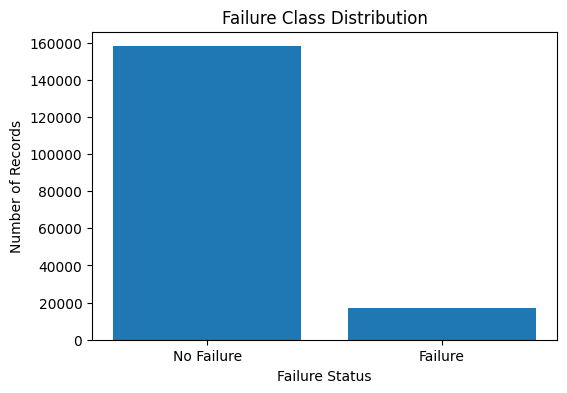

In [ ]:
import matplotlib.pyplot as plt

# Plot failure distribution
failure_counts = df["Failure_Probability"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["No Failure", "Failure"], failure_counts.values)
plt.xlabel("Failure Status")
plt.ylabel("Number of Records")
plt.title("Failure Class Distribution")
plt.show()

In [ ]:
# Feature selection

features = [
    "Battery_Voltage",
    "Battery_Current",
    "Battery_Temperature",
    "Motor_Temperature",
    "Motor_Vibration",
    "Motor_RPM",
    "Motor_Torque",
    "Power_Consumption",
    "Brake_Pressure",
    "Driving_Speed",
    "Distance_Traveled",
    "Charge_Cycles"
]

target = "Failure_Probability"

X = df[features]
y = df[target]

print("Number of features:", len(features))
print("\nFeatures:")
for feature in features:
    print("-", feature)

display(df[features].describe().T)

Number of features: 12

Features:
- Battery_Voltage
- Battery_Current
- Battery_Temperature
- Motor_Temperature
- Motor_Vibration
- Motor_RPM
- Motor_Torque
- Power_Consumption
- Brake_Pressure
- Driving_Speed
- Distance_Traveled
- Charge_Cycles


,count,mean,std,min,25%,50%,75%,max
Battery_Voltage,175393.0,352.713482,55.246513,200.001095,355.989733,370.587405,385.262527,399.999314
Battery_Current,175393.0,-47.892493,45.358339,-199.994036,-45.270093,-33.518350,-21.757595,-10.000173
Battery_Temperature,175393.0,33.399346,8.655192,25.000010,27.948170,30.887664,33.826187,59.997570
Motor_Temperature,175393.0,56.027332,15.447305,40.000182,45.872695,51.757365,57.678209,99.999997
Motor_Vibration,175393.0,0.523942,0.434352,0.200000,0.288583,0.376488,0.465118,1.999954
Motor_RPM,175393.0,2235.503735,1188.119583,1500.005873,1646.972583,1793.947006,1941.249131,5999.999833
Motor_Torque,175393.0,179.786407,76.767046,100.000039,129.469691,158.810055,188.025425,399.998498
Power_Consumption,175393.0,31.702128,16.398066,20.000007,22.922685,25.875666,28.809528,79.999908
Brake_Pressure,175393.0,46.036323,15.434657,30.000025,35.903621,41.759191,47.668778,89.999940
Driving_Speed,175393.0,58.254410,20.599544,40.000040,45.906363,51.776604,57.669053,119.998280


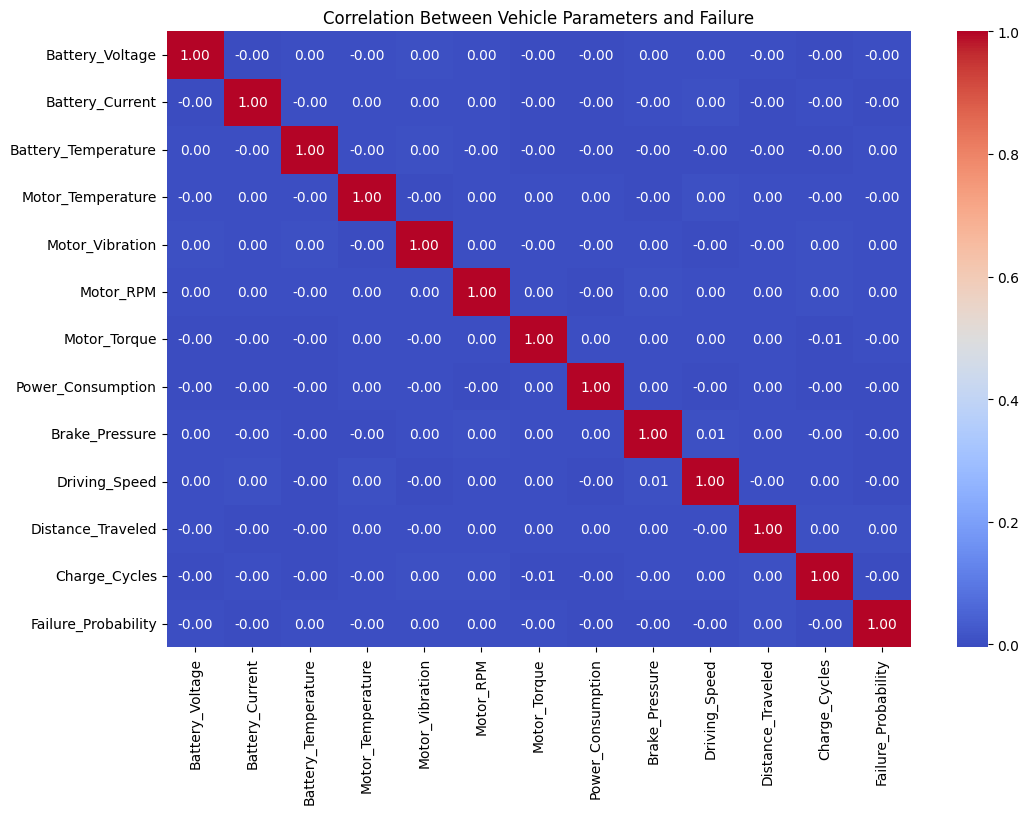

In [ ]:
# Correlation heatmap
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(
    df[features + [target]].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Between Vehicle Parameters and Failure")
plt.show()

In [ ]:
# Train-Test split
split_index = int(len(df) * 0.80)

train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Training data: (140314, 12)
Testing data: (35079, 12)

Training target:
Failure_Probability
0    126464
1     13850
Name: count, dtype: int64

Testing target:
Failure_Probability
0    31597
1     3482
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler

# Scalinf to standardize features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (140314, 12)
Scaled testing shape: (35079, 12)


In [ ]:
# Model 1: Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, lr_pred, zero_division=0))

print("ROC-AUC:", round(roc_auc_score(y_test, lr_prob), 4))

              precision    recall  f1-score   support

           0       0.90      0.56      0.69     31597
           1       0.10      0.43      0.16      3482

    accuracy                           0.55     35079
   macro avg       0.50      0.50      0.43     35079
weighted avg       0.82      0.55      0.64     35079

ROC-AUC: 0.4932


In [ ]:
# Model 2: Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, rf_pred, zero_division=0))

print("ROC-AUC:", round(roc_auc_score(y_test, rf_prob), 4))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95     31597
           1       0.00      0.00      0.00      3482

    accuracy                           0.90     35079
   macro avg       0.45      0.50      0.47     35079
weighted avg       0.81      0.90      0.85     35079

ROC-AUC: 0.5068


In [ ]:
# Model 3: XGBoost

# Install XGBoost
!pip -q install xgboost

from xgboost import XGBClassifier

negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

print("Non-failure:", negative)
print("Failure:", positive)
print("Scale positive weight:", round(negative / positive, 2))

Non-failure: 126464
Failure: 13850
Scale positive weight: 9.13


In [ ]:
# Train XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=negative / positive,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, xgb_pred, zero_division=0))

print("ROC-AUC:", round(roc_auc_score(y_test, xgb_prob), 4))

              precision    recall  f1-score   support

           0       0.90      0.64      0.75     31597
           1       0.10      0.38      0.16      3482

    accuracy                           0.62     35079
   macro avg       0.50      0.51      0.46     35079
weighted avg       0.82      0.62      0.69     35079

ROC-AUC: 0.5162


In [ ]:
# Model 4: LSTM
import numpy as np

sequence_length = 10

def create_sequences(X, y, sequence_length):
    X_seq = []
    y_seq = []

    for i in range(sequence_length, len(X)):
        X_seq.append(X[i-sequence_length:i])
        y_seq.append(y[i])

    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train.values,
    sequence_length
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    y_test.values,
    sequence_length
)

print("Training sequences:", X_train_seq.shape)
print("Testing sequences:", X_test_seq.shape)

Training sequences: (140304, 10, 12)
Testing sequences: (35069, 10, 12)


In [ ]:
# LSTM class weights
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_seq)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_seq
)

class_weights = dict(zip(classes, weights))

print("Class weights:", class_weights)

Class weights: {np.int64(0): np.float64(0.5547542228126779), np.int64(1): np.float64(5.065857885615252)}


In [ ]:
# Build LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input

lstm_model = Sequential([
    Input(shape=(sequence_length, len(features))),
    LSTM(64),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,825 (85.25 KB)

 Trainable params: 21,825 (85.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train LSTM
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=30,
    batch_size=256,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
439/439 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.4971 - loss: 0.6951 - val_accuracy: 0.5265 - val_loss: 0.6920
Epoch 2/30
439/439 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.5062 - loss: 0.6938 - val_accuracy: 0.4622 - val_loss: 0.6973
Epoch 3/30
439/439 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - accuracy: 0.5203 - loss: 0.6933 - val_accuracy: 0.5537 - val_loss: 0.6903
Epoch 4/30
439/439 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.5140 - loss: 0.6929 - val_accuracy: 0.3594 - val_loss: 0.7065
Epoch 5/30
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.5139 - loss: 0.6925 - val_accuracy: 0.5000 - val_loss: 0.6947
Epoch 6/30
439/439 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.5234 - loss: 0.6918 - val_accuracy: 0.4689 - val_loss: 0.6943
Epoch 7/30
439/439 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.5042 - loss: 0.6913 - val_accuracy: 0.6572 - val_loss: 0.6755
Epoch 8/30
439/439 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - accuracy: 0.5361 - loss: 0.6905 - 

In [ ]:
# Evaluate LSTM
lstm_prob = lstm_model.predict(
    X_test_seq,
    verbose=0
).ravel()

lstm_pred = (lstm_prob >= 0.5).astype(int)

print(classification_report(
    y_test_seq,
    lstm_pred,
    zero_division=0
))

print("ROC-AUC:", round(
    roc_auc_score(y_test_seq, lstm_prob), 4
))

              precision    recall  f1-score   support

           0       0.90      0.69      0.78     31587
           1       0.10      0.32      0.15      3482

    accuracy                           0.65     35069
   macro avg       0.50      0.50      0.47     35069
weighted avg       0.82      0.65      0.72     35069

ROC-AUC: 0.5037


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.5475,0.0979,0.4334,0.1598,0.4932
1,Random Forest,0.9007,0.0000,0.0000,0.0000,0.5068
2,XGBoost,0.6163,0.1047,0.3797,0.1642,0.5162
3,LSTM,0.6501,0.1013,0.3205,0.1539,0.5037


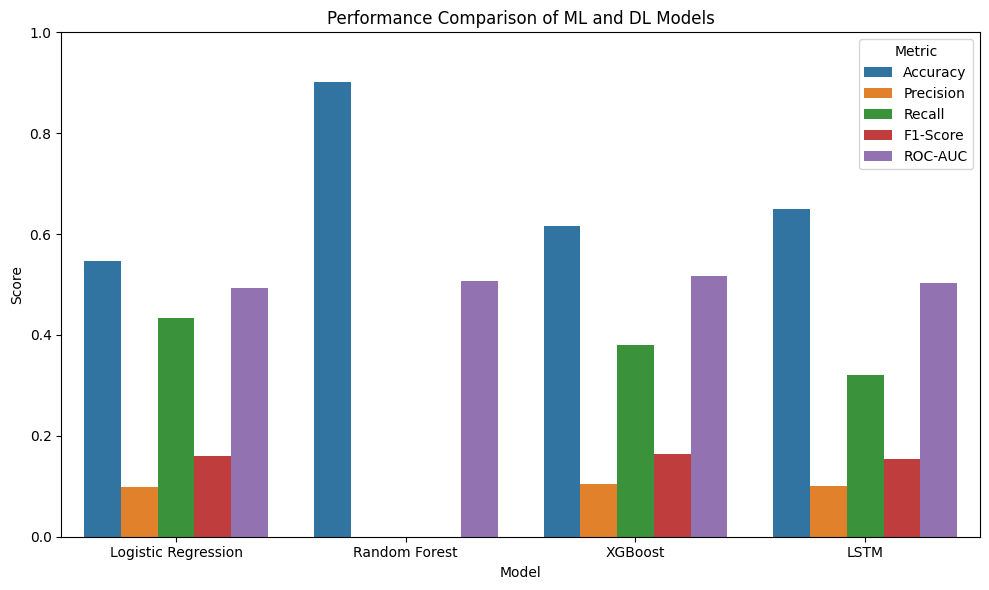

In [ ]:
# Model comparison
results = []

def add_result(name, y_true, y_pred, y_prob):
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    })

add_result("Logistic Regression", y_test, lr_pred, lr_prob)
add_result("Random Forest", y_test, rf_pred, rf_prob)
add_result("XGBoost", y_test, xgb_pred, xgb_prob)
add_result("LSTM", y_test_seq, lstm_pred, lstm_prob)

results_df = pd.DataFrame(results)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

results_melted = results_df.melt(
    id_vars="Model",
    value_vars=metrics,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.ylim(0, 1)
plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Performance Comparison of ML and DL Models")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

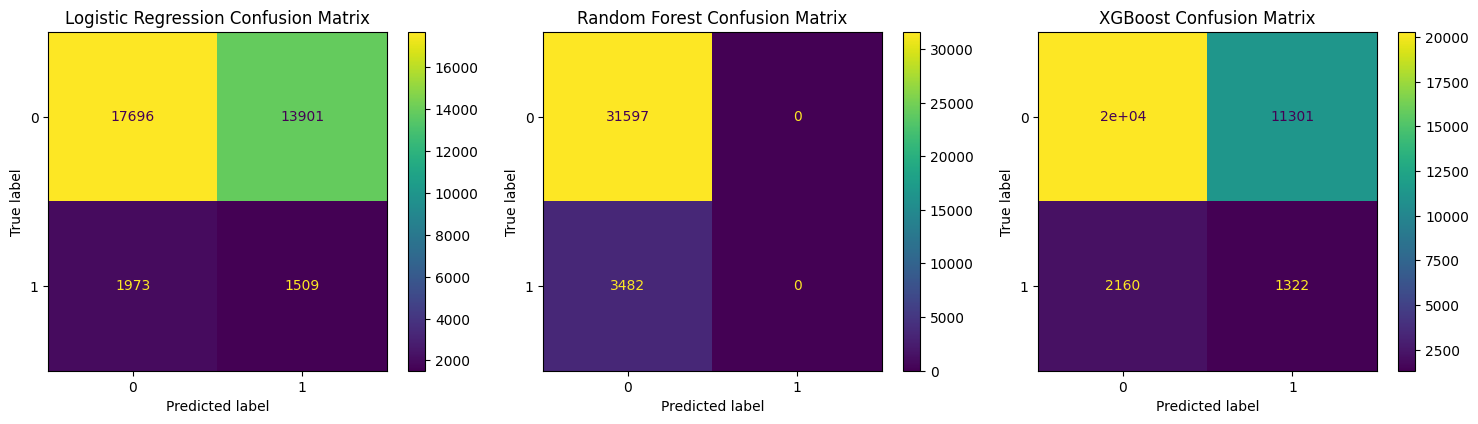

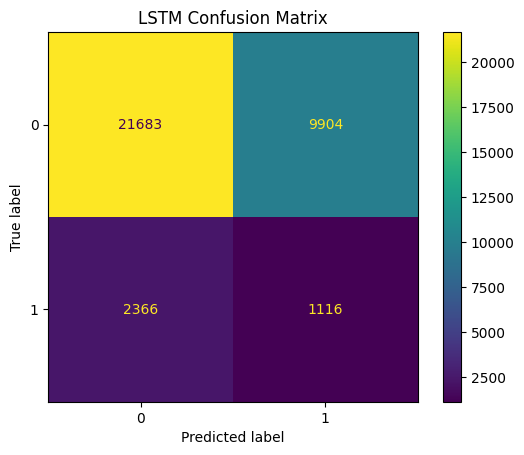

In [ ]:
# Confusion Marices
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred, ax=axes[0]
)
axes[0].set_title("Logistic Regression Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(
    y_test, rf_pred, ax=axes[1]
)
axes[1].set_title("Random Forest Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(
    y_test, xgb_pred, ax=axes[2]
)
axes[2].set_title("XGBoost Confusion Matrix")

plt.tight_layout()
plt.show()

ConfusionMatrixDisplay.from_predictions(
    y_test_seq,
    lstm_pred
)

plt.title("LSTM Confusion Matrix")
plt.show()

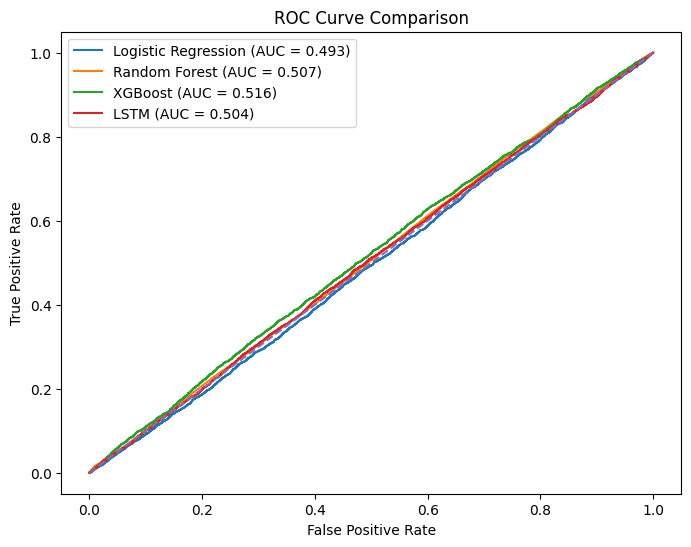

In [ ]:
# ROC Curves
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for name, y_true, y_prob in [
    ("Logistic Regression", y_test, lr_prob),
    ("Random Forest", y_test, rf_prob),
    ("XGBoost", y_test, xgb_prob),
    ("LSTM", y_test_seq, lstm_prob)
]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
# Explainability: XGBoost
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

display(importance_df)

,Feature,Importance
0,Battery_Voltage,0.084442
4,Motor_Vibration,0.084166
6,Motor_Torque,0.084001
9,Driving_Speed,0.083977
10,Distance_Traveled,0.083622
3,Motor_Temperature,0.083582
11,Charge_Cycles,0.083579
2,Battery_Temperature,0.083544
1,Battery_Current,0.083433
8,Brake_Pressure,0.082651


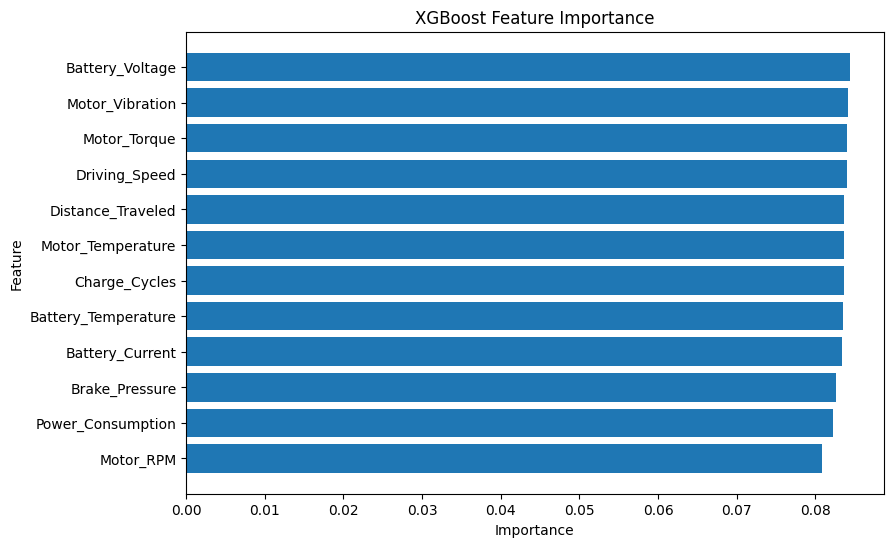

In [ ]:
# Feature importance plot
plt.figure(figsize=(9, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Health score
monitoring_df = test_df[["Timestamp"] + features].copy()

monitoring_df["Failure_Probability"] = xgb_prob

monitoring_df["Health_Score"] = (
    1 - monitoring_df["Failure_Probability"]
) * 100

# Status and maintenance alert
def get_status(score):
    if score >= 70:
        return "NORMAL"
    elif score >= 40:
        return "WARNING"
    else:
        return "CRITICAL"

def get_alert(status):
    if status == "NORMAL":
        return "No immediate maintenance alert"
    elif status == "WARNING":
        return "Maintenance inspection recommended"
    else:
        return "Immediate maintenance attention required"

monitoring_df["Status"] = monitoring_df["Health_Score"].apply(get_status)
monitoring_df["Maintenance_Alert"] = monitoring_df["Status"].apply(get_alert)

display(
    monitoring_df[
        [
            "Timestamp",
            "Failure_Probability",
            "Health_Score",
            "Status",
            "Maintenance_Alert"
        ]
    ].head(10)
)

,Timestamp,Failure_Probability,Health_Score,Status,Maintenance_Alert
140314,2024-01-01 14:30:00,0.506287,49.371273,WARNING,Maintenance inspection recommended
140315,2024-01-01 14:45:00,0.498296,50.170444,WARNING,Maintenance inspection recommended
140316,2024-01-01 15:00:00,0.458322,54.167770,WARNING,Maintenance inspection recommended
140317,2024-01-01 15:15:00,0.456687,54.331310,WARNING,Maintenance inspection recommended
140318,2024-01-01 15:30:00,0.513768,48.623245,WARNING,Maintenance inspection recommended
140319,2024-01-01 15:45:00,0.484844,51.515568,WARNING,Maintenance inspection recommended
140320,2024-01-01 16:00:00,0.467182,53.281807,WARNING,Maintenance inspection recommended
140321,2024-01-01 16:15:00,0.510749,48.925060,WARNING,Maintenance inspection recommended
140322,2024-01-01 16:30:00,0.532928,46.707165,WARNING,Maintenance inspection recommended
140323,2024-01-01 16:45:00,0.473844,52.615559,WARNING,Maintenance inspection recommended


In [ ]:
# Final vehicle monitoring output
sample = monitoring_df.iloc[0]

print("Vehicle Health Monitoring System")
print("--------------------------------")
print(f"Vehicle Health: {sample['Health_Score']:.2f}%")
print(f"Failure Probability: {sample['Failure_Probability'] * 100:.2f}%")
print(f"Status: {sample['Status']}")
print(f"Maintenance Alert: {sample['Maintenance_Alert']}")

Vehicle Health Monitoring System
--------------------------------
Vehicle Health: 49.37%
Failure Probability: 50.63%
Status: WARNING
Maintenance Alert: Maintenance inspection recommended
